# gradient-boosted tree

In [1]:
import pandas as pd

In [2]:
from dataengineers import Dataset

In [3]:
dataset = Dataset('train')
train, test = dataset.build_train_test()

In [4]:
exclude = ['id', 'target', 'delivery_start', 'market', 'market_int', 'timestamp_int', 'day_of_year', 'dayofweek', 'hour']

In [5]:
features = [c for c in train.columns if c not in exclude]

In [6]:
from models import XGB

In [7]:
xg = XGB(features)

In [8]:
xg.fit(train, test)

[0]	validation_0-rmse:152.78195	validation_1-rmse:51.81822
[100]	validation_0-rmse:90.26804	validation_1-rmse:63.54842
[115]	validation_0-rmse:84.79424	validation_1-rmse:66.13812


In [9]:
y_vals = xg.predict(test)

/home/matt/repos/nitor-comp/.venv/lib/python3.14/site-packages/xgboost/core.py:751: UserWarning: [11:03:48] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [10]:
from utils import rmse

In [11]:
rmse(test['target'], y_vals)

np.float64(51.17150897709929)

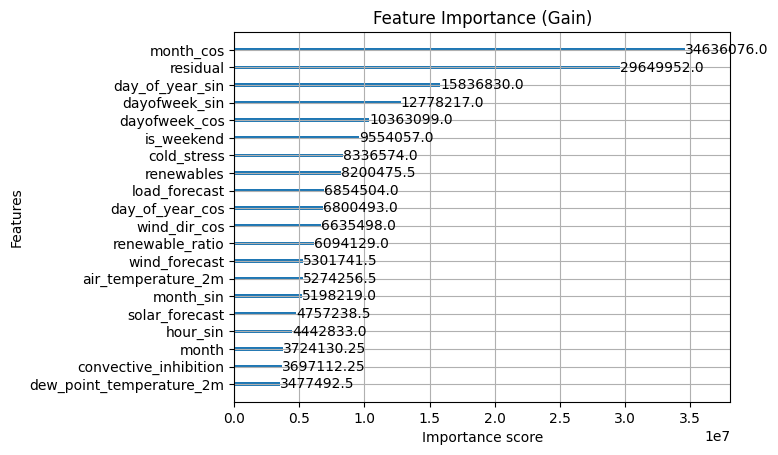

In [12]:
xg.stats()

In [13]:
ds2 = Dataset('test')

In [14]:
df_out = ds2.build_main()

In [15]:
y_out = xg.predict(df_out)

In [16]:
df_out['target'] = y_out

In [17]:
df_out.head()

,id,global_horizontal_irradiance,diffuse_horizontal_irradiance,direct_normal_irradiance,cloud_cover_total,cloud_cover_low,cloud_cover_mid,cloud_cover_high,precipitation_amount,visibility,...,day_of_year_sin,day_of_year_cos,renewables,renewable_ratio,residual,cold_stress,wind_dir_sin,wind_dir_cos,market_int,target
0,133627,0.0,0.0,0.0,100.0,14.0,44.0,100.0,0.0,16600.0,...,-0.871706,-0.490029,3662.2,0.066356,51527.2742,257.469501,0.188847,0.982007,0,35.918022
1,133635,0.0,0.0,0.0,100.0,100.0,100.0,88.0,0.0,13800.0,...,-0.871706,-0.490029,2922.5,0.055155,50063.9471,258.119501,0.976548,0.215302,0,35.780113
2,133643,0.0,0.0,0.0,100.0,70.0,100.0,100.0,0.0,19700.0,...,-0.871706,-0.490029,2199.1,0.042885,49079.3655,258.819500,0.894428,-0.447213,0,35.780113
3,133651,0.0,0.0,0.0,99.0,13.0,99.0,94.0,0.0,16200.0,...,-0.871706,-0.490029,1795.5,0.035635,48589.6570,258.669500,-0.938343,-0.345707,0,35.780113
4,133659,0.0,0.0,0.0,96.0,0.0,96.0,79.0,0.0,14500.0,...,-0.871706,-0.490029,1477.5,0.029582,48468.1642,258.669500,0.707106,0.707108,0,35.780113


In [18]:
from utils import Submission

In [19]:
submit = Submission(df_out)

In [20]:
submit.process()

,id,target
0,133627,35.918022
2183,133629,35.150879
4366,133630,35.150879
10915,133631,35.150879
6549,133633,35.150879
...,...,...
4365,146774,35.215229
6548,146775,34.760990
13097,146776,34.083183
8731,146777,34.139500


In [21]:
submit.validate()

✅ Validation passed!


In [22]:
submit.dump()